In [1]:
import pandas as pd 
import numpy as np
df = pd.read_csv('fer2013.csv')

In [2]:
df.head()

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [3]:
df.shape

(35887, 3)

In [4]:
len(df.iloc[0,1])

8287

In [5]:
pixels = df.loc[2,'pixels']
img = np.array(pixels.split(),dtype=np.uint8)
img = img.reshape(48,48)

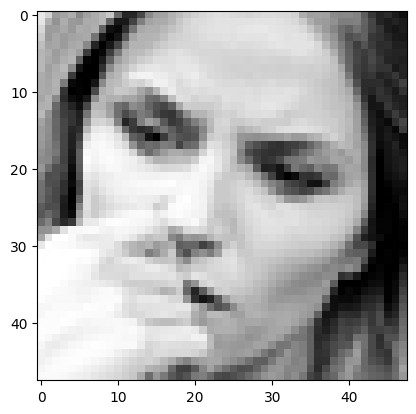

In [6]:
import matplotlib.pyplot as plt
plt.imshow(img,cmap='grey')
plt.show()

In [7]:
imgs = []
for i in range(df.shape[0]):
    pixels = df.loc[i,'pixels']
    img = np.array(pixels.split(),dtype=np.uint8)
    imgs.append(img)

X = pd.DataFrame(imgs)
X

# X = np.array(df['pixels'].str.split().tolist(), dtype=np.uint8)

,0,1,2,3,4,5,6,7,8,9,...,2294,2295,2296,2297,2298,2299,2300,2301,2302,2303
0,70,80,82,72,58,58,60,63,54,58,...,159,182,183,136,106,116,95,106,109,82
1,151,150,147,155,148,133,111,140,170,174,...,105,108,95,108,102,67,171,193,183,184
2,231,212,156,164,174,138,161,173,182,200,...,104,138,152,122,114,101,97,88,110,152
3,24,32,36,30,32,23,19,20,30,41,...,174,126,132,132,133,136,139,142,143,142
4,4,0,0,0,0,0,0,0,0,0,...,12,34,31,31,31,27,31,30,29,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35882,50,36,17,22,23,29,33,39,34,37,...,216,215,216,217,221,222,220,223,221,216
35883,178,174,172,173,181,188,191,194,196,199,...,147,141,136,118,66,7,0,0,0,0
35884,17,17,16,23,28,22,19,17,25,26,...,190,179,193,193,194,170,148,154,133,113
35885,30,28,28,29,31,30,42,68,79,81,...,30,27,27,26,28,35,35,35,30,28


In [8]:
y = df.loc[:,'emotion']

In [9]:
y

0        0
1        0
2        2
3        4
4        6
        ..
35882    6
35883    3
35884    0
35885    3
35886    2
Name: emotion, Length: 35887, dtype: int64

In [10]:
y.nunique()

7

Label	Emotion
0	Angry 😠
1	Disgust 🤢
2	Fear 😨
3	Happy 😊
4	Sad 😢
5	Surprise 😲
6	Neutral 😐

In [11]:
X.max(axis=0)

0       255
1       255
2       255
3       255
4       255
       ... 
2299    255
2300    255
2301    255
2302    255
2303    255
Length: 2304, dtype: uint8

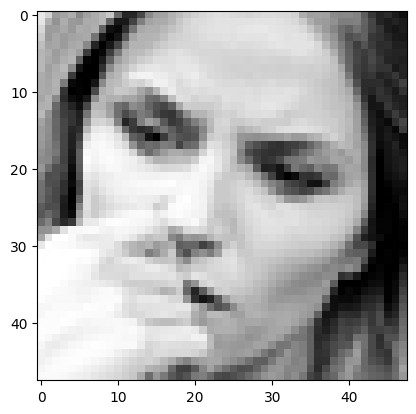

In [12]:
img0 = X.iloc[2].values.reshape(48,48)
plt.imshow(img0,cmap='grey')
plt.show()

In [13]:
X = X/255

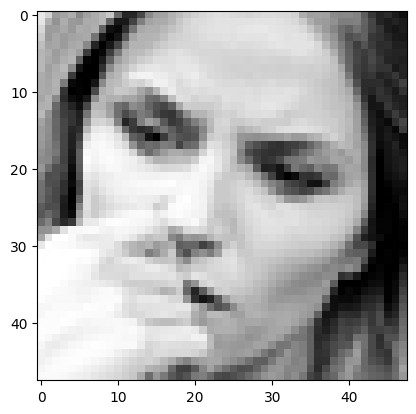

In [14]:
img0 = X.iloc[2].values.reshape(48,48)
plt.imshow(img0,cmap='grey')
plt.show()

In [15]:
X = X.values.reshape(-1,48,48,1)

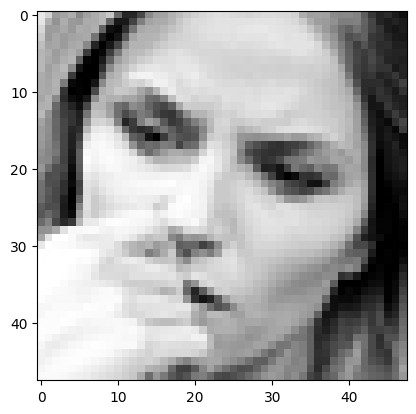

In [48]:
img1 = X[2]
plt.imshow(img1,cmap='grey')
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 7,stratify=y)
# Stratify preserves the class distribution of the 7 emotions in both train and test sets.

In [17]:
X_train.shape

(28709, 48, 48, 1)

In [18]:
y_train.shape

(28709,)

In [19]:
y_test.shape

(7178,)

In [20]:
from tensorflow.keras.utils import to_categorical
y_cat_train = to_categorical(y_train,7)
y_cat_test = to_categorical(y_test,7)

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten,Dropout, BatchNormalization

model = Sequential()
model.add(Conv2D(filters=32,kernel_size=(3,3),input_shape=(48,48,1),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),padding='same'))
model.add(Conv2D(filters=64,kernel_size=(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),padding='same'))
model.add(Conv2D(filters=128,kernel_size=(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),padding='same'))
model.add(Conv2D(filters=256,kernel_size=(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),padding='same'))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(7,activation='softmax'))

model.summary()

C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 46, 46, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 46, 46, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 23, 23, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 21, 21, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 21, 21, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 11, 11, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 9, 9, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 9, 9, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 5, 5, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 3, 3, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 3, 3, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 2, 2, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         131,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 521,863 (1.99 MB)

 Trainable params: 520,903 (1.99 MB)

 Non-trainable params: 960 (3.75 KB)

In [36]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor = 'val_loss', patience=2, restore_best_weights=True)

In [ ]:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator

# datagen = ImageDataGenerator(
#     rotation_range=15,
#     width_shift_range=0.1,
#     height_shift_range=0.1,
#     horizontal_flip=True
# )
# Using image augmentation decreases accuracy that's why not used

In [37]:
model.fit(X_train, y_cat_train, batch_size=32,epochs=20,validation_data=(X_test,y_cat_test),callbacks=[early_stop])

Epoch 1/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 91s 93ms/step - accuracy: 0.3637 - loss: 1.6526 - val_accuracy: 0.4191 - val_loss: 1.4993
Epoch 2/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 83s 92ms/step - accuracy: 0.4561 - loss: 1.4086 - val_accuracy: 0.3631 - val_loss: 1.5803
Epoch 3/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 83s 93ms/step - accuracy: 0.5066 - loss: 1.2997 - val_accuracy: 0.5220 - val_loss: 1.2578
Epoch 4/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 90s 100ms/step - accuracy: 0.5411 - loss: 1.2079 - val_accuracy: 0.5085 - val_loss: 1.2584
Epoch 5/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 88s 98ms/step - accuracy: 0.5692 - loss: 1.1372 - val_accuracy: 0.5157 - val_loss: 1.2620


In [38]:
losses = pd.DataFrame(model.history.history)
losses

,accuracy,loss,val_accuracy,val_loss
0,0.363719,1.652620,0.419058,1.499332
1,0.456094,1.408576,0.363054,1.580274
2,0.506566,1.299718,0.522012,1.257833
3,0.541120,1.207896,0.508498,1.258387
4,0.569229,1.137224,0.515743,1.262004


<Axes: >

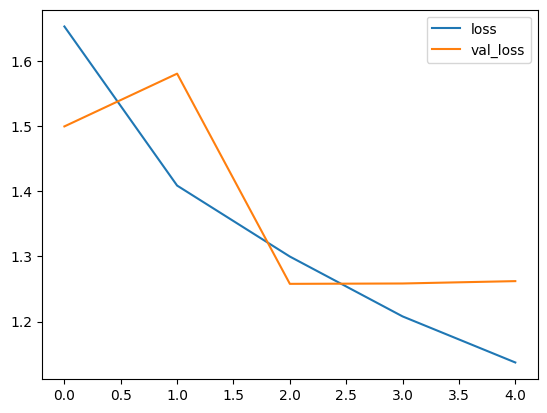

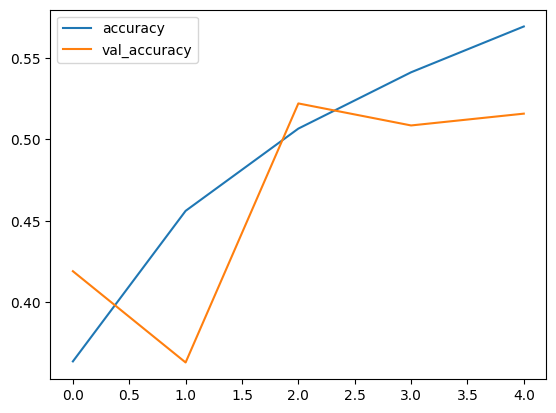

In [39]:
losses[['loss','val_loss']].plot()
losses[['accuracy','val_accuracy']].plot()

In [40]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob,axis=1)

225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step


In [42]:
from sklearn.metrics import confusion_matrix,classification_report
print(confusion_matrix(y_test,y_pred))

[[ 239    0   37  136  306   40  233]
 [  35    0    5    8   38    5   18]
 [  82    0  118  114  343  138  229]
 [  27    0   16 1452  161   27  115]
 [  50    0   27  129  652   21  337]
 [  13    0   55   73   51  537   71]
 [  16    0   13  154  291   17  749]]


In [43]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.52      0.24      0.33       991
           1       0.00      0.00      0.00       109
           2       0.44      0.12      0.18      1024
           3       0.70      0.81      0.75      1798
           4       0.35      0.54      0.43      1216
           5       0.68      0.67      0.68       800
           6       0.43      0.60      0.50      1240

    accuracy                           0.52      7178
   macro avg       0.45      0.43      0.41      7178
weighted avg       0.52      0.52      0.49      7178



C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [45]:
model.save("emotion_detector.keras")

In [1]:
emotion_map = {
    0:'Angry',
    1:'Disgust',
    2:'Fear',
    3:'Happy',
    4:'Sad',
    5:'Surprise',
    6:'Neutral'
}


In [70]:
img = X_test[648]
img = img.reshape(1,48,48,1)
pred = model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


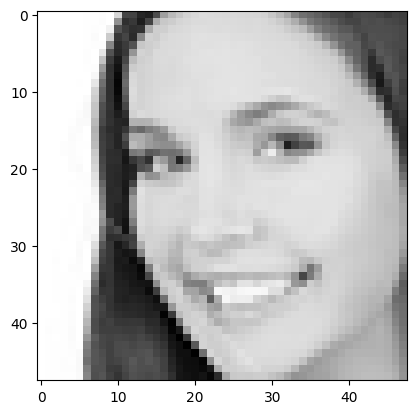

Happy


In [71]:
plt.imshow(img.reshape(48,48),cmap='grey')
plt.show()
print(emotion_map[pred.argmax()])

In [87]:
import cv2

img = cv2.imread("img5.png")           # Color image
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

gray = cv2.resize(gray, (48,48))
gray = gray / 255.0

gray = gray.reshape(1,48,48,1)

pred = model.predict(gray)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


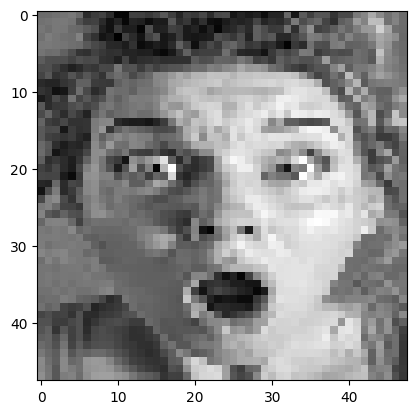

Surprise


In [88]:
plt.imshow(gray.reshape(48,48),cmap='grey')
plt.show()
print(emotion_map[pred.argmax()])